# Eksperiment menggunakan google/mt5-small

In [ ]:
# Cek GPU
import torch
print(torch.cuda.is_available())

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Menggunakan perangkat: {device}")

True
Menggunakan perangkat: cuda


###***Ambil Dataset dari Kaggle***

In [ ]:
# Upload ke Google Colab

from google.colab import files
files.upload()

In [ ]:
# Set Permission
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Install Kaggle CLI
!pip install kaggle

In [ ]:
# Download Dataset
# url : https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2

!kaggle datasets download -d nalaprogroup/clean-data-project2

Dataset URL: https://www.kaggle.com/datasets/nalaprogroup/clean-data-project2
License(s): CC0-1.0
100% 15.7M/15.7M [00:03<00:00, 5.09MB/s]



In [ ]:
# Extract File
!unzip clean-data-project2.zip

Archive:  clean-data-project2.zip
  inflating: dev_data_convert.json   
  inflating: dev_text_clean.json     
  inflating: test_data_convert.json  
  inflating: test_text_clean.json    
  inflating: train_data_convert.json  
  inflating: train_text_clean.json   


In [ ]:
# memindahkan file ke sample_data/liputan6
!mkdir -p /content/sample_data/liputan6

!mv dev_data_convert.json /content/sample_data/liputan6
!mv train_data_convert.json /content/sample_data/liputan6
!mv test_data_convert.json /content/sample_data/liputan6

!mv dev_text_clean.json /content/sample_data/liputan6
!mv test_text_clean.json /content/sample_data/liputan6
!mv train_text_clean.json /content/sample_data/liputan6

###***Dataset***

In [ ]:
# Load 1 sample dulu
import json

with open('/content/sample_data/liputan6/train_text_clean.json') as f:
    data_train = json.load(f)

print("Jml train_text_clean :",len(data_train))

with open('/content/sample_data/liputan6/dev_text_clean.json') as g:
    data_dev = json.load(g)

print("Jml dev_text_clean :",len(data_dev))


with open('/content/sample_data/liputan6/test_text_clean.json') as h:
    data_test = json.load(h)

print("Jml test_text_clean :",len(data_test))


sample = data_train[0]

print("ID:\n", sample['id'])
print("ARTICLE:\n", sample['clean_article'])
print("\nClean SUMMARY:\n", sample['clean_summary'])
print("\nSUMMARY:\n", sample['extractive_summary'])

Jml train_text_clean : 5000
Jml dev_text_clean : 5000
Jml test_text_clean : 5000
ID:
 198679
ARTICLE:
 Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musim tanam para petani harus mengeluarkan b

In [ ]:
# Validasi otomatis  - Abstractive Summary/Clean_Summary

empty_summary_idx = []

for i, sample in enumerate(data_train):
    summary = sample.get('clean_summary', None)

    if summary is None or summary.strip() == "":
        empty_summary_idx.append(i)

print("Jumlah summary kosong:", len(empty_summary_idx))
print("Contoh index:", empty_summary_idx[:10])

Jumlah summary kosong: 0
Contoh index: []


In [ ]:
# Cek Clean_Summary yang kosong
for i in empty_summary_idx[:5]:
    print(f"\n=== DATA INDEX {i} ===")
    print("ARTICLE:\n", data_train[i]['clean_article'])
    print("\nSUMMARY:\n", data_train[i]['clean_summary'])

# google/mt5-small Start

In [ ]:
# DISINI ADA SCRIPT TOKEN HUGGING FACE SEHARUSNYA
# DIDELETE UNTUK KEPERLUAN GIT
# JIKA INGIN LOGIN HUGGING FACE, BUKA SCRIPT IMPORT DAN LOGIN

# from huggingface_hub import login

# login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
# Install & Import Library

# !pip install transformers datasets sentencepiece -q
# !pip install transformers datasets evaluate rouge_score
!pip install transformers[torch] datasets evaluate rouge_score accelerate sentencepiece -U

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 20.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 100.3 MB/s eta 0:00:00
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=fb8e4121e0bbfc8714d4d5e22b278684efe4ca09245dd08dacf7e8fbbf954e6a
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: 

In [ ]:
# Import Library

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
#    Trainer,
#    TrainingArguments,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer
)

from datasets import Dataset
import evaluate
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Convert ke HuggingFace Dataset
# from datasets import Dataset

train_dataset = Dataset.from_list(data_train)
dev_dataset = Dataset.from_list(data_dev)
test_dataset = Dataset.from_list(data_test)

In [ ]:
# pembatasan dataset
train_dataset = train_dataset.select(range(10))
dev_dataset = dev_dataset.select(range(10))
test_dataset = test_dataset.select(range(10))

In [ ]:
# cek dataset

print(train_dataset)

for i in range(3):
    print(train_dataset[i])
    print("="*50)

#print(len(train_dataset[0]["clean_article"]))
#print(len(train_dataset[0]["clean_summary"]))

print("="*50)

print(train_dataset.column_names)

Dataset({
    features: ['id', 'clean_article', 'clean_summary', 'extractive_summary'],
    num_rows: 5000
})
{'id': 198679, 'clean_article': 'Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musi

In [ ]:
# menyesuaikan kolom untuk dataset

# mengubah nama kolom
train_dataset = train_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

dev_dataset = dev_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

test_dataset = test_dataset.rename_columns({
    "clean_article": "article",
    "clean_summary": "summary"
})

# menghapus kolom tidak digunakan
train_dataset = train_dataset.remove_columns(["id", "extractive_summary"])
dev_dataset = dev_dataset.remove_columns(["id", "extractive_summary"])
test_dataset = test_dataset.remove_columns(["id", "extractive_summary"])

In [ ]:
print(train_dataset[0])

{'article': 'Puluhan petani di Polewali Mandar, Sulawesi Barat, membakar lahan pertanian mereka. Ini dilakukan sebagai bentuk protes atas kinerja pemerintah yang dinilai lamban menangani bencana kekeringan akibat jebolnya bendungan Sekka-Sekka pasacabanjir bandang Januari lalu. Jebolnya bendungan membuat distribusi air terhenti. Menurut Abdul Rasyid, petani setempat, mereka kesal dan frustrasi karena padinya tak segera mendapat pasokan air yang cukup. Bahkan, sebagian petani menyerahkan lahannya pada peternak sapi untuk dijadikan pakan ternak. Kepala Dusun Nepo, Kecamatan Wonomulyo, Logawali, menjelaskan, bendungan sudah hampir dua bulan rusak. Namun hingga kini belum ada upaya perbaikan yang berarti. Pemerintah beralasan karena tidak ada dana perbaikan. Bencana kekeringan akibat kurangnya pasokan air merupakan yang kesekian kalinya. Padahal setiap kali musim tanam para petani harus mengeluarkan biaya hingga jutaan rupiah. Bahkan tidak jarang berhutang kepada tengkulak hanya untuk memb

In [ ]:
import numpy as np

article_lens = [len(x["article"]) for x in train_dataset]
summary_lens = [len(x["summary"]) for x in train_dataset]

print("Avg article:", np.mean(article_lens))
print("Avg summary:", np.mean(summary_lens))

Avg article: 1340.9384
Avg summary: 193.072


In [ ]:
# Load model google/mt5-small

model_name = "google/mt5-small"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

config.json:   0%|          | 0.00/553 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/82.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.20G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [ ]:
# KONFIGURASI MODEL (Ubah perilaku model)

from transformers import GenerationConfig

# 1. Definisikan konfigurasi generasi yang baru
generation_config = GenerationConfig(
    max_length=64,
    min_length=20,
    num_beams=5,
    early_stopping=True,
    length_penalty=2.0,
    no_repeat_ngram_size=3,
    decoder_start_token_id=model.config.decoder_start_token_id,
    eos_token_id=model.config.eos_token_id,
    pad_token_id=model.config.pad_token_id,
)

# 2. Masukkan konfigurasi ini ke dalam model
model.generation_config = generation_config

In [ ]:
# PREPROCESS

def preprocess_function(examples):
    inputs = ["summarize: " + doc for doc in examples["article"]]

    model_inputs = tokenizer(
        inputs,
        max_length=512,
        truncation=True,
        padding="max_length"
    )

    labels = tokenizer(
        examples["summary"],
        max_length=150,
        truncation=True,
        padding="max_length"
    )

    # masking padding token
    labels["input_ids"] = [
        [(l if l != tokenizer.pad_token_id else -100) for l in label]
        for label in labels["input_ids"]
    ]

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [ ]:
# Tokenization

tokenized_train = train_dataset.map(preprocess_function, batched=True)
tokenized_dev   = dev_dataset.map(preprocess_function, batched=True)
tokenized_test  = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [ ]:
tokenized_train[0]

In [ ]:
# metric

rouge = evaluate.load("rouge")

import numpy as np

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    # Pastikan predictions adalah array numpy
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    # Kadang predictions berisi ID yang di luar range karena proses generation
    # Kita clip atau bersihkan jika perlu, tapi biasanya masalah ada di labels

    # PERBAIKAN UTAMA: Pastikan labels benar-benar bersih dari -100
    # Ganti semua -100 dengan pad_token_id (biasanya 0 pada mT5)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Decode dengan pengamanan tambahan
    decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # Lanjutkan ke perhitungan ROUGE...
    result = rouge.compute(predictions=decoded_preds, references=decoded_labels, use_stemmer=True)

    return {
        "rouge1": round(result["rouge1"] * 100, 4),
        "rouge2": round(result["rouge2"] * 100, 4),
        "rougeL": round(result["rougeL"] * 100, 4)
    }

In [ ]:
# TRAINING ARGUMENTS
training_args = Seq2SeqTrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",        # Sudah diperbaiki dari sebelumnya
    save_strategy="epoch",
#    learning_rate=3e-5,
    learning_rate=1e-5,
    report_to="none",
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=100,
    save_total_limit=2,
    fp16=False,
    bf16=False,                # Pastikan ini juga False
    predict_with_generate=True
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# Data Collator

data_collator = DataCollatorForSeq2Seq(
    tokenizer,
    model=model,
    label_pad_token_id=-100, # Memastikan padding label ditandai -100
    pad_to_multiple_of=None
#    pad_to_multiple_of=8 if training_args.fp16 else None # Optimasi untuk FP16
)

In [ ]:
# TRAINER

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    data_collator=data_collator,
    processing_class=tokenizer, # <-- Coba ganti 'tokenizer' menjadi 'processing_class'
    compute_metrics=compute_metrics
)

In [ ]:
# TRAINING
trainer.train()

Epoch,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel
1,3.582743,2.608978,25.158700,12.638600,21.344500
2,3.059450,2.538117,28.652000,15.523700,24.454100
3,2.948354,2.511321,29.556500,16.126500,25.242300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7500, training_loss=4.519942565917969, metrics={'train_runtime': 9206.1751, 'train_samples_per_second': 1.629, 'train_steps_per_second': 0.815, 'total_flos': 7931245363200000.0, 'train_loss': 4.519942565917969, 'epoch': 3.0})

In [ ]:
results_predict = trainer.predict(tokenized_test)
print(results_predict.metrics)

{'test_loss': 2.5113210678100586, 'test_rouge1': 29.5565, 'test_rouge2': 16.1265, 'test_rougeL': 25.2423, 'test_runtime': 2247.703, 'test_samples_per_second': 2.224, 'test_steps_per_second': 1.112}


In [ ]:
# Simpan model dan tokenizer ke satu folder khusus
model_path = "./model_final_summarization"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./model_final_summarization/tokenizer_config.json',
 './model_final_summarization/tokenizer.json')

In [ ]:
!zip -r model_summarization.zip ./model_final_summarization

  adding: model_final_summarization/ (stored 0%)
  adding: model_final_summarization/model.safetensors (deflated 24%)
  adding: model_final_summarization/training_args.bin (deflated 53%)
  adding: model_final_summarization/generation_config.json (deflated 58%)
  adding: model_final_summarization/config.json (deflated 49%)
  adding: model_final_summarization/tokenizer.json (deflated 76%)
  adding: model_final_summarization/tokenizer_config.json (deflated 85%)


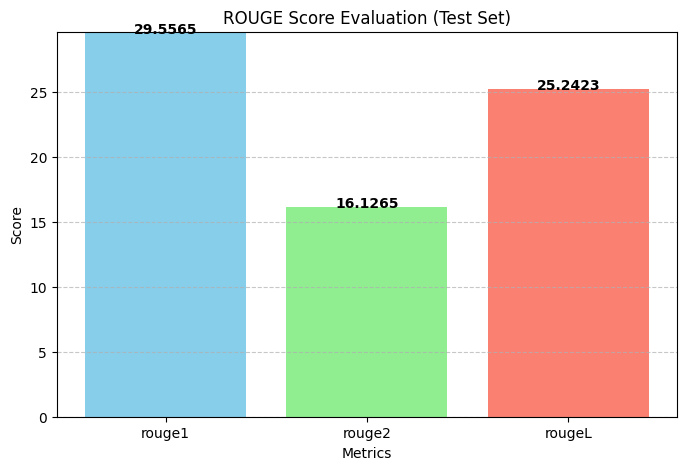

In [ ]:
# VISUALISASI HASIL results_predict

# Ambil metrik dari hasil predict (biasanya berawalan 'test_')
# Kita gunakan .get() agar tidak error jika key tidak ditemukan
metrics_names = ["rouge1", "rouge2", "rougeL"]
scores = [results_predict.metrics.get(f"test_{m}", 0) for m in metrics_names]

# Jika kamu ingin menampilkan dalam skala 0-100 (persen)
# scores = [s * 100 for s in scores]

plt.figure(figsize=(8, 5))
plt.bar(metrics_names, scores, color=['skyblue', 'lightgreen', 'salmon'])

# Tambahkan angka di atas bar agar lebih jelas
for i, v in enumerate(scores):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.title("ROUGE Score Evaluation (Test Set)")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.ylim(0, max(scores) + 0.1 if scores else 1) # Beri ruang di atas bar
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np

# Ambil hasil prediksi teks
predictions = results_predict.predictions
labels = results_predict.label_ids

# Decode menjadi teks
decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

# Lihat 3 contoh pertama
for i in range(100, 106):
    print(f"Prediksi: {decoded_preds[i]}")
    print(f"Asli    : {decoded_labels[i]}")
    print("-" * 30)

Prediksi: <extra_id_0> DPR akan membahas mekanisme revisi Anggaran Pendapatan dan Belanja Negara 2001.
Asli    : Revisi Anggaran Pendapatan dan Belanja Negara 2001 mungkin dilakukan dengan penyesuaian. Pencabutan subsidi akan membebani masyarakat. Sebaliknya jika tidak akan memberakan APBN.
------------------------------
Prediksi: <extra_id_0> penjahat spesialis orang asing dan nasabah bank, Ahad (26/8). Ketiganya adalah Wiwin, Fredy Banjar, dan Samuel.
Asli    : Wiwin, Fredy Banjar, dan Samuel ditangkap polisi lantaran diduga kerap malakukan kejahatan terhadap nasabah bank dan orang asing. Selama aksi, mereka telah meraup keuntungan sekitar Rp 300 juta.
------------------------------
Prediksi: <extra_id_0> Hakim Agung Syafiuddin Kartasasmita serta kepemilikan senjata tajam dan amunisi, Rabu (26/12) pukul 13. 30 WIB.
Asli    : Gelar Perkara kasus Tommy Soeharto berlangsung dihadapan Tim Penyidik Kejati Jakarta. Dua perkara yang digelar adalah kasus pembunuhan dan kepemilikan senjata ap

In [ ]:
# INFERENCE

def summarize(text):
    # Tentukan device (cek apakah model ada di cuda atau cpu)
    device = next(model.parameters()).device

    inputs = tokenizer(
        "summarize: " + text,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device) # <--- TAMBAHKAN INI: Pindahkan semua tensor input ke GPU

    outputs = model.generate(
        inputs["input_ids"],
        max_length=150,
        num_beams=4,
        early_stopping=True
    )

    # Decode hasil
    decoded_output = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # MEMBERSIHKAN TAG <extra_id_0>
    clean_output = decoded_output.replace("<extra_id_0>", "").strip()

    return clean_output

# contoh
print(summarize(train_dataset[1000]["article"]))

kasus pembalakan liar terhadap 13 perusahaan kayu dibela Polri.


In [ ]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.8 MB/s eta 0:00:00


In [ ]:
import evaluate
import numpy as np
import pandas as pd

def run_full_evaluation(predictions, references):
    print("Wait... Sedang menghitung metrik (ini mungkin memakan waktu beberapa menit)...")

    # 1. Load Metrics
    rouge_metric = evaluate.load("rouge")
    bertscore_metric = evaluate.load("bertscore")

    # 2. Hitung ROUGE
    # rouge_types bisa disesuaikan, standar: rouge1, rouge2, rougeL
    rouge_results = rouge_metric.compute(
        predictions=predictions,
        references=references,
        use_stemmer=True
    )

    # 3. Hitung BERTScore
    # Menggunakan model multilingual yang mendukung Bahasa Indonesia (lang="id")
    # Di Colab Pro, proses ini akan otomatis menggunakan GPU jika tersedia
    bert_results = bertscore_metric.compute(
        predictions=predictions,
        references=references,
        lang="id"
    )

    # 4. Rangkum Hasil ke dalam DataFrame agar rapi
    summary_dict = {
        "Metric": ["ROUGE-1", "ROUGE-2", "ROUGE-L", "BERTScore Precision", "BERTScore Recall", "BERTScore F1"],
        "Score": [
            rouge_results["rouge1"],
            rouge_results["rouge2"],
            rouge_results["rougeL"],
            np.mean(bert_results["precision"]),
            np.mean(bert_results["recall"]),
            np.mean(bert_results["f1"])
        ]
    }

    df_results = pd.DataFrame(summary_dict)

    # Menampilkan tabel hasil
    print("\n" + "="*30)
    print("HASIL EVALUASI MODEL")
    print("="*30)
    print(df_results.to_string(index=False))
    print("="*30)

    return df_results

# --- EKSEKUSI ---
# Menggunakan variabel decoded_preds dan decoded_labels yang sudah Anda miliki
evaluation_report = run_full_evaluation(decoded_preds, decoded_labels)

# Tambahan: Melihat perbandingan data spesifik (misal indeks 100-105) untuk kualitatif
print("\nSampel Perbandingan (Indeks 100-105):")
for i in range(100, 106):
    print(f"\n[Data {i}]")
    # Membersihkan tag <extra_id_0> jika masih ada
    p = decoded_preds[i].replace("<extra_id_0>", "").strip()
    l = decoded_labels[i].strip()
    print(f"Prediksi : {p}")
    print(f"Asli     : {l}")

Wait... Sedang menghitung metrik (ini mungkin memakan waktu beberapa menit)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



HASIL EVALUASI MODEL
             Metric    Score
            ROUGE-1 0.295493
            ROUGE-2 0.161208
            ROUGE-L 0.252312
BERTScore Precision 0.709622
   BERTScore Recall 0.728646
       BERTScore F1 0.718784

Sampel Perbandingan (Indeks 100-105):

[Data 100]
Prediksi : DPR akan membahas mekanisme revisi Anggaran Pendapatan dan Belanja Negara 2001.
Asli     : Revisi Anggaran Pendapatan dan Belanja Negara 2001 mungkin dilakukan dengan penyesuaian. Pencabutan subsidi akan membebani masyarakat. Sebaliknya jika tidak akan memberakan APBN.

[Data 101]
Prediksi : penjahat spesialis orang asing dan nasabah bank, Ahad (26/8). Ketiganya adalah Wiwin, Fredy Banjar, dan Samuel.
Asli     : Wiwin, Fredy Banjar, dan Samuel ditangkap polisi lantaran diduga kerap malakukan kejahatan terhadap nasabah bank dan orang asing. Selama aksi, mereka telah meraup keuntungan sekitar Rp 300 juta.

[Data 102]
Prediksi : Hakim Agung Syafiuddin Kartasasmita serta kepemilikan senjata tajam dan amunisi

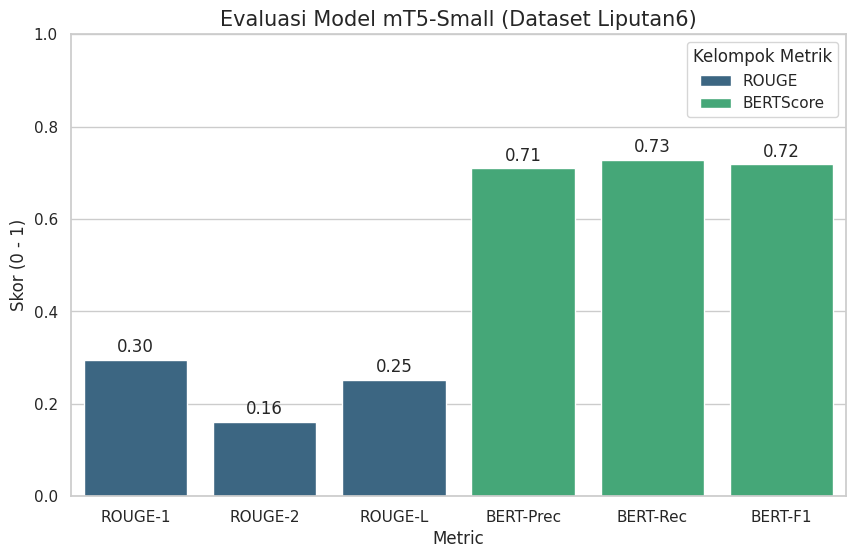

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data dari hasil evaluasi Anda
data = {
    'Metric': ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'BERT-Prec', 'BERT-Rec', 'BERT-F1'],
    'Score': [0.2955, 0.1612, 0.2523, 0.7096, 0.7286, 0.7188],
    'Category': ['ROUGE', 'ROUGE', 'ROUGE', 'BERTScore', 'BERTScore', 'BERTScore']
}

df = pd.DataFrame(data)

# Set style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Membuat Bar Plot
ax = sns.barplot(x='Metric', y='Score', hue='Category', data=df, palette='viridis')

# Menambahkan angka di atas bar
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(format(p.get_height(), '.2f'),
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points')

plt.title('Evaluasi Model mT5-Small (Dataset Liputan6)', fontsize=15)
plt.ylim(0, 1.0) # Skala 0 sampai 1
plt.ylabel('Skor (0 - 1)')
plt.legend(title='Kelompok Metrik')
plt.show()